# CoAtNet - WaRP-C 28-Class Classification



## Install Libraries

In [2]:
# timm is the library that has the CoAtNet model
# scikit-learn is used to calculate metrics like precision recall f1 and auc
!pip install timm scikit-learn --quiet

## Upload the Dataset



In [3]:
# this shows a choose files button
# click it and pick the zip file
from google.colab import files
uploaded = files.upload()

# printing the name to confirm the file uploaded properly
print("Uploaded:", list(uploaded.keys())[0])

Saving WaRP-C-preprocessed.zip to WaRP-C-preprocessed.zip
Uploaded: WaRP-C-preprocessed.zip


## Unzip the Dataset

In [4]:
import os
import zipfile

# getting the name of the file we just uploaded
zip_filename = list(uploaded.keys())[0]

# building the full path to the zip inside colab
zip_path = f"/content/{zip_filename}"

# this is the folder where all images will go after extracting
extract_dir = "/content/WaRP-C"

# checking if we already extracted so we dont do it again on rerun
if not os.path.exists(extract_dir):
    print("Extracting...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)  # unzipping everything into extract_dir
    print("Done!")
else:
    print("Already extracted.")

# printing folder names to confirm train val and test are there
print("Contents:", os.listdir(extract_dir))

Extracting...
Done!
Contents: ['train', 'test', 'val']


## Import All Libraries

In [5]:
import time                          # to track how long training takes
import numpy as np                   # for working with arrays and numbers
import matplotlib.pyplot as plt      # for drawing all the graphs
import seaborn as sns                # makes the confusion matrix look nicer
import torch                         # main deep learning framework
import torch.nn as nn               # has things like loss functions
import torch.optim as optim         # has the optimiser to update model weights
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
# Dataset is the base class for our custom loader
# DataLoader feeds images to the model in batches
# WeightedRandomSampler helps fix the class imbalance problem
from torchvision import transforms  # for image augmentation
from PIL import Image               # for opening image files
import timm                         # library that has the CoAtNet model
from sklearn.metrics import (
    classification_report,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize  # needed for roc curves

# using gpu if its available otherwise using cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Custom Dataset - 28 Classes

Instead of grouping subfolders into 5 parent classes, we now treat each subfolder as its own class.

So `bottle-blue`, `bottle-green`, `glass-dark` etc. are all **separate classes**.
This gives us **28 classes** total.

In [6]:
# listing all 28 class names - each subfolder is its own class
# sorted() puts them in alphabetical order so the numbering is always the same
CLASS_NAMES = sorted([
    "bottle-blue", "bottle-blue-full", "bottle-blue5l", "bottle-blue5l-full",
    "bottle-dark", "bottle-dark-full", "bottle-green", "bottle-green-full",
    "bottle-milk", "bottle-milk-full", "bottle-multicolor", "bottle-multicolorv-full",
    "bottle-oil",  "bottle-oil-full",  "bottle-transp",    "bottle-transp-full",
    "bottle-yogurt", "glass-dark", "glass-green", "glass-transp",
    "canister", "cans",
    "juice-cardboard", "milk-cardboard",
    "detergent-box", "detergent-color", "detergent-transparent", "detergent-white"
])

# the model needs numbers not names so we map each class to an index
# e.g. bottle-blue = 0, bottle-blue-full = 1 and so on
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}

print(f"Total classes: {len(CLASS_NAMES)}")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  {idx:2d} : {name}")


class WaRPDataset(Dataset):
    # our custom dataset class to handle the 2-level folder structure
    # images are inside subfolders which are inside the main class folders

    def __init__(self, root_dir, transform=None):
        self.transform = transform  # transforms to apply on each image
        self.samples   = []         # stores (image path, class number) pairs

        # looping through the 5 main folders: bottle canister cans cardboard detergent
        for parent in os.listdir(root_dir):
            parent_path = os.path.join(root_dir, parent)
            if not os.path.isdir(parent_path):
                continue  # skip if not a folder

            # looping through subfolders like bottle-blue glass-dark etc
            for subfolder in os.listdir(parent_path):
                sub_path = os.path.join(parent_path, subfolder)
                if not os.path.isdir(sub_path):
                    continue  # skip if not a folder
                if subfolder not in CLASS_TO_IDX:
                    continue  # skip anything not in our 28 class list

                # getting the class number for this subfolder
                class_idx = CLASS_TO_IDX[subfolder]

                # going through every image in this subfolder
                for fname in os.listdir(sub_path):
                    if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                        img_path = os.path.join(sub_path, fname)
                        self.samples.append((img_path, class_idx))  # saving path and label

        self.classes      = CLASS_NAMES
        self.class_to_idx = CLASS_TO_IDX
        self.targets      = [lbl for _, lbl in self.samples]  # just the labels as a list

    def __len__(self):
        # returns how many images are in the dataset
        return len(self.samples)

    def __getitem__(self, idx):
        # called by the dataloader to get one image and its label
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")  # opening image as rgb
        if self.transform:
            image = self.transform(image)  # applying transforms
        return image, label

print("Custom dataset class ready.")

Total classes: 28
   0 : bottle-blue
   1 : bottle-blue-full
   2 : bottle-blue5l
   3 : bottle-blue5l-full
   4 : bottle-dark
   5 : bottle-dark-full
   6 : bottle-green
   7 : bottle-green-full
   8 : bottle-milk
   9 : bottle-milk-full
  10 : bottle-multicolor
  11 : bottle-multicolorv-full
  12 : bottle-oil
  13 : bottle-oil-full
  14 : bottle-transp
  15 : bottle-transp-full
  16 : bottle-yogurt
  17 : canister
  18 : cans
  19 : detergent-box
  20 : detergent-color
  21 : detergent-transparent
  22 : detergent-white
  23 : glass-dark
  24 : glass-green
  25 : glass-transp
  26 : juice-cardboard
  27 : milk-cardboard
Custom dataset class ready.


## Folder Paths

In [7]:
# paths to the train val and test folders inside the extracted dataset
train_dir = os.path.join(extract_dir, "train")
val_dir   = os.path.join(extract_dir, "val")
test_dir  = os.path.join(extract_dir, "test")

print("Train dir:", train_dir)
print("Val dir  :", val_dir)
print("Test dir :", test_dir)

Train dir: /content/WaRP-C/train
Val dir  : /content/WaRP-C/val
Test dir : /content/WaRP-C/test


## Augmentation

Augmentation applied on-the-fly during training only. Val and test images are not augmented.

In [8]:
# imagenet mean and std - we use these because coatnet was pretrained on imagenet
# normalising with these values puts images in the range the model expects
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# training transforms - augmentation is randomly applied on the fly each epoch
# this helps the model not memorise the training images
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),                              # randomly flip left to right
    transforms.RandomVerticalFlip(),                                # randomly flip upside down
    transforms.RandomRotation(15),                                  # randomly rotate up to 15 degrees
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),  # random colour changes
    transforms.RandomGrayscale(p=0.1),                             # 10% chance of turning black and white
    transforms.ToTensor(),                                          # converting image to tensor
    transforms.Normalize(MEAN, STD)                                # normalising pixel values
])

# val and test transforms - no augmentation so evaluation is fair and consistent
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

print("Transforms ready.")

Transforms ready.


## Load the Dataset

In [10]:
# loading all three splits using our custom dataset class
train_dataset = WaRPDataset(train_dir, transform=train_transform)
val_dataset   = WaRPDataset(val_dir,   transform=val_transform)
test_dataset  = WaRPDataset(test_dir,  transform=val_transform)

print(f"Train : {len(train_dataset)} images")
print(f"Val   : {len(val_dataset)} images")
print(f"Test  : {len(test_dataset)} images")
print(f"Classes: {len(train_dataset.classes)} total")

# saving the number of classes - we need this when building the model
num_classes = len(train_dataset.classes)  # should be 28
print(f"Number of classes: {num_classes}")

Train : 7058 images
Val   : 1765 images
Test  : 1551 images
Classes: 28 total
Number of classes: 28


## Class Distribution Graph

Shows how many images each of the 28 classes has. Important to see imbalance before training.

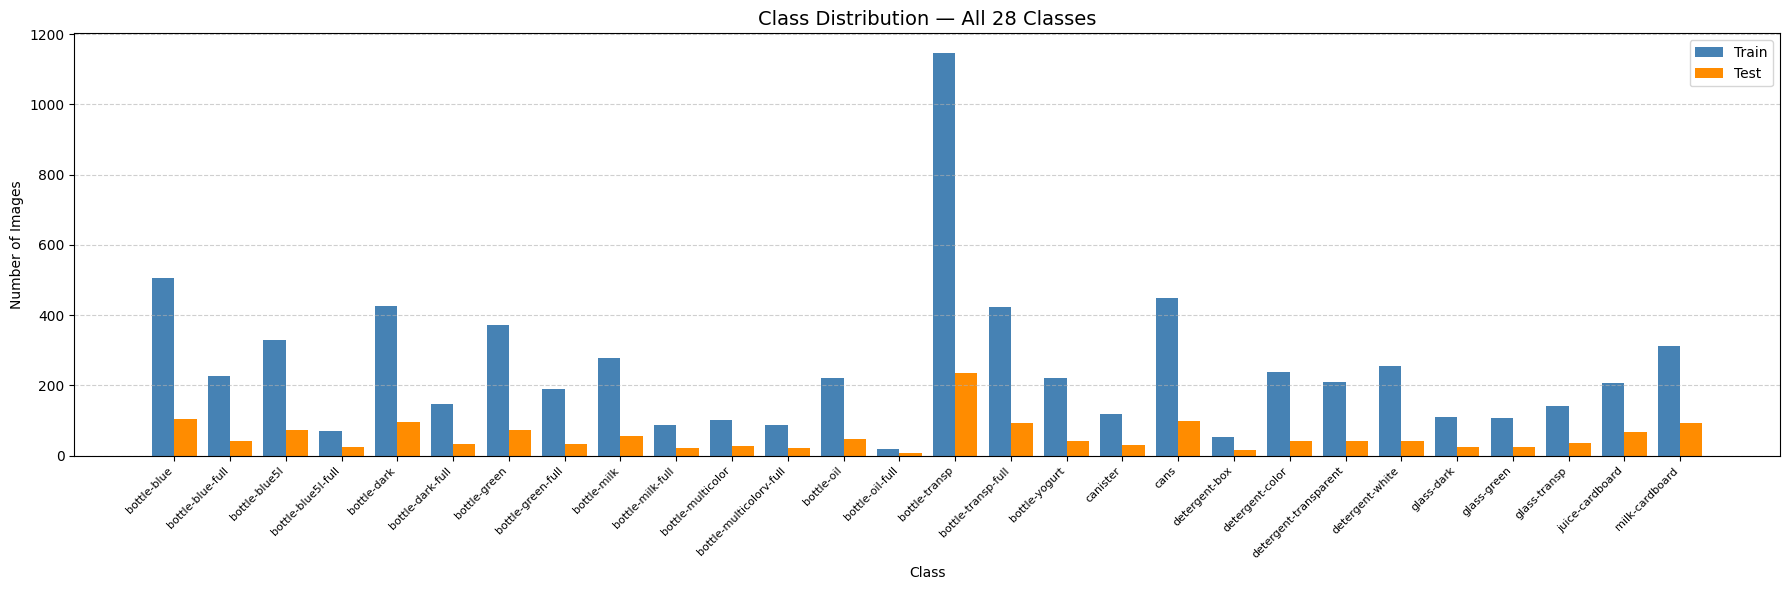

Saved: class_distribution.png


In [11]:
class_names = train_dataset.classes

# counting how many images each class has in train and test
train_counts = [(np.array(train_dataset.targets) == i).sum() for i in range(num_classes)]
test_counts  = [(np.array(test_dataset.targets)  == i).sum() for i in range(num_classes)]

# setting up x positions - one group of bars per class
x = np.arange(num_classes)
width = 0.4

# making the figure wide enough to fit all 28 class names
fig, ax = plt.subplots(figsize=(18, 6))
ax.bar(x - width/2, train_counts, width, label="Train", color="steelblue")
ax.bar(x + width/2, test_counts,  width, label="Test",  color="darkorange")

ax.set_title("Class Distribution — All 28 Classes", fontsize=14)
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
ax.set_xticks(x)
# rotating labels 45 degrees so they dont overlap each other
ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("/content/class_distribution.png", dpi=150)
plt.show()
print("Saved: class_distribution.png")

## Handling Class Imbalance



In [12]:
# getting the class label for every training image
train_targets = np.array(train_dataset.targets)

# counting how many images belong to each class
class_counts = np.bincount(train_targets)

# classes with fewer images get a higher weight
# so the model is forced to pay more attention to rare classes
class_weights = 1.0 / class_counts

# converting weights to a tensor and sending to gpu
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# weighted loss means the model gets penalised more for getting rare classes wrong
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("Class counts:")
for i, (name, count) in enumerate(zip(CLASS_NAMES, class_counts)):
    print(f"  {name:30s} : {count} images")

# assigning a weight to every single training image based on its class
# images from rare classes will be picked more often
sample_weights = class_weights[train_targets]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(sample_weights),  # same number of images drawn per epoch
    replacement=True                  # same image can be picked more than once
)

print("\nImbalance handling ready.")

Class counts:
  bottle-blue                    : 507 images
  bottle-blue-full               : 228 images
  bottle-blue5l                  : 330 images
  bottle-blue5l-full             : 71 images
  bottle-dark                    : 426 images
  bottle-dark-full               : 148 images
  bottle-green                   : 373 images
  bottle-green-full              : 190 images
  bottle-milk                    : 278 images
  bottle-milk-full               : 88 images
  bottle-multicolor              : 102 images
  bottle-multicolorv-full        : 86 images
  bottle-oil                     : 221 images
  bottle-oil-full                : 19 images
  bottle-transp                  : 1145 images
  bottle-transp-full             : 422 images
  bottle-yogurt                  : 222 images
  canister                       : 119 images
  cans                           : 449 images
  detergent-box                  : 53 images
  detergent-color                : 237 images
  detergent-transparent 

## Data Loaders

In [13]:
# how many images are processed in one go
# reduce to 16 if you get a cuda out of memory error
BATCH_SIZE = 32

# training loader uses the weighted sampler to balance the classes
# no shuffle needed because the sampler already handles the ordering
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=2, pin_memory=True)

# val and test loaders just go through images in order
# no augmentation and no shuffling needed here
val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

print("Data loaders ready.")

Data loaders ready.


## Build the CoAtNet Model

In [14]:
# loading coatnet-0 with pretrained imagenet weights
# pretrained=True means the model already knows basic features like edges and textures
# num_classes=28 sets the output layer to predict 28 classes
model = timm.create_model("coatnet_0_rw_224", pretrained=True, num_classes=num_classes)
model = model.to(device)  # sending the model to gpu

# counting total learnable parameters to understand model size
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params/1e6:.1f}M")
print(f"Output classes  : {num_classes}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

Total parameters: 26.7M
Output classes  : 28


## Optimiser and Scheduler

In [15]:
# adamw works well with models like coatnet
# lr=1e-4 is the learning rate - how big each weight update step is
# weight_decay prevents the weights from growing too large which can cause overfitting
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

# if val accuracy doesnt improve for 3 epochs the lr gets halved
# this helps squeeze out better performance in later epochs
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

print("Optimiser and scheduler ready.")

Optimiser and scheduler ready.


## Training Loop

Runs for 20 epochs. Prints loss and val accuracy after each epoch. Saves the best model automatically.

In [16]:
NUM_EPOCHS = 20  # how many times we go through the full training data

# these lists store the loss and accuracy after each epoch for plotting
train_losses   = []
val_accuracies = []

best_val_acc    = 0.0  # tracks the best accuracy seen so far
best_model_path = "/content/best_coatnet_28class.pth"  # where we save the best model

training_start = time.time()  # recording start time

for epoch in range(NUM_EPOCHS):

    # training phase
    model.train()  # training mode - dropout on and batchnorm updates
    running_loss = 0.0
    epoch_start  = time.time()

    for images, labels in train_loader:
        images = images.to(device)  # moving images to gpu
        labels = labels.to(device)  # moving labels to gpu

        optimizer.zero_grad()              # clearing gradients from last step
        outputs = model(images)            # getting predictions from model
        loss    = criterion(outputs, labels)  # how wrong the predictions are
        loss.backward()                    # calculating gradients
        optimizer.step()                   # updating the model weights

        running_loss += loss.item()  # adding this batch loss to total

    # average loss across all batches this epoch
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # validation phase
    model.eval()  # eval mode - dropout off
    correct, total = 0, 0

    with torch.no_grad():  # no gradients needed during validation
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)  # picking the highest scoring class
            total   += labels.size(0)  # total images seen
            correct += (predicted == labels).sum().item()  # how many were correct

    val_acc = 100.0 * correct / total  # accuracy as a percentage
    val_accuracies.append(val_acc)

    scheduler.step(val_acc)  # reduce lr if accuracy has stopped improving

    # saving the model only when it beats the previous best
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    epoch_time = time.time() - epoch_start
    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}]  "
          f"Loss: {avg_train_loss:.4f}  |  "
          f"Val Acc: {val_acc:.2f}%  |  "
          f"Time: {epoch_time:.1f}s")

total_training_time = time.time() - training_start
print(f"\nDone. Total time: {total_training_time/60:.1f} mins")
print(f"Best val accuracy: {best_val_acc:.2f}%")

Epoch [01/20]  Loss: 1.4276  |  Val Acc: 39.38%  |  Time: 114.2s
Epoch [02/20]  Loss: 0.5772  |  Val Acc: 58.70%  |  Time: 122.4s
Epoch [03/20]  Loss: 0.3735  |  Val Acc: 64.19%  |  Time: 122.7s
Epoch [04/20]  Loss: 0.3475  |  Val Acc: 63.06%  |  Time: 124.3s
Epoch [05/20]  Loss: 0.2844  |  Val Acc: 69.97%  |  Time: 124.2s
Epoch [06/20]  Loss: 0.2066  |  Val Acc: 65.67%  |  Time: 123.9s
Epoch [07/20]  Loss: 0.1629  |  Val Acc: 69.86%  |  Time: 124.0s
Epoch [08/20]  Loss: 0.1793  |  Val Acc: 71.61%  |  Time: 124.5s
Epoch [09/20]  Loss: 0.1845  |  Val Acc: 60.17%  |  Time: 124.9s
Epoch [10/20]  Loss: 0.1518  |  Val Acc: 71.44%  |  Time: 124.5s
Epoch [11/20]  Loss: 0.1090  |  Val Acc: 74.67%  |  Time: 124.5s
Epoch [12/20]  Loss: 0.1275  |  Val Acc: 70.37%  |  Time: 124.3s
Epoch [13/20]  Loss: 0.1022  |  Val Acc: 69.41%  |  Time: 123.9s
Epoch [14/20]  Loss: 0.2068  |  Val Acc: 67.37%  |  Time: 124.5s
Epoch [15/20]  Loss: 0.1349  |  Val Acc: 72.01%  |  Time: 123.8s
Epoch [16/20]  Loss: 0.05

### Graph - Training Loss

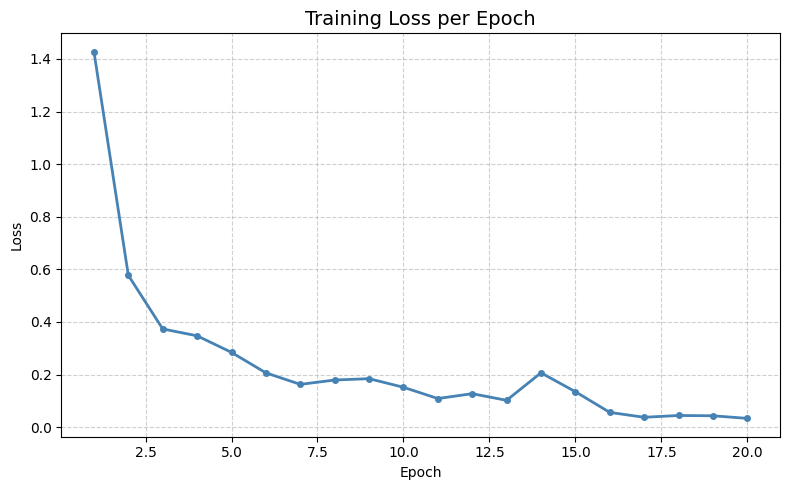

Saved: training_loss.png


In [17]:
# creating x axis values - one number per epoch
epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, color="steelblue", linewidth=2, marker="o", markersize=4)
plt.title("Training Loss per Epoch", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("/content/training_loss.png", dpi=150)
plt.show()
print("Saved: training_loss.png")

### Graph - Validation Accuracy

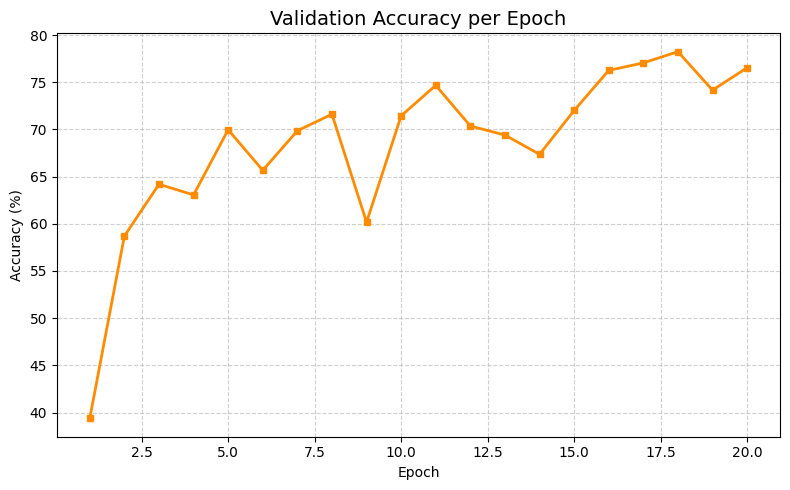

Saved: val_accuracy.png


In [18]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, val_accuracies, color="darkorange", linewidth=2, marker="s", markersize=4)
plt.title("Validation Accuracy per Epoch", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("/content/val_accuracy.png", dpi=150)
plt.show()
print("Saved: val_accuracy.png")

### Graph — Loss and Accuracy Side by Side

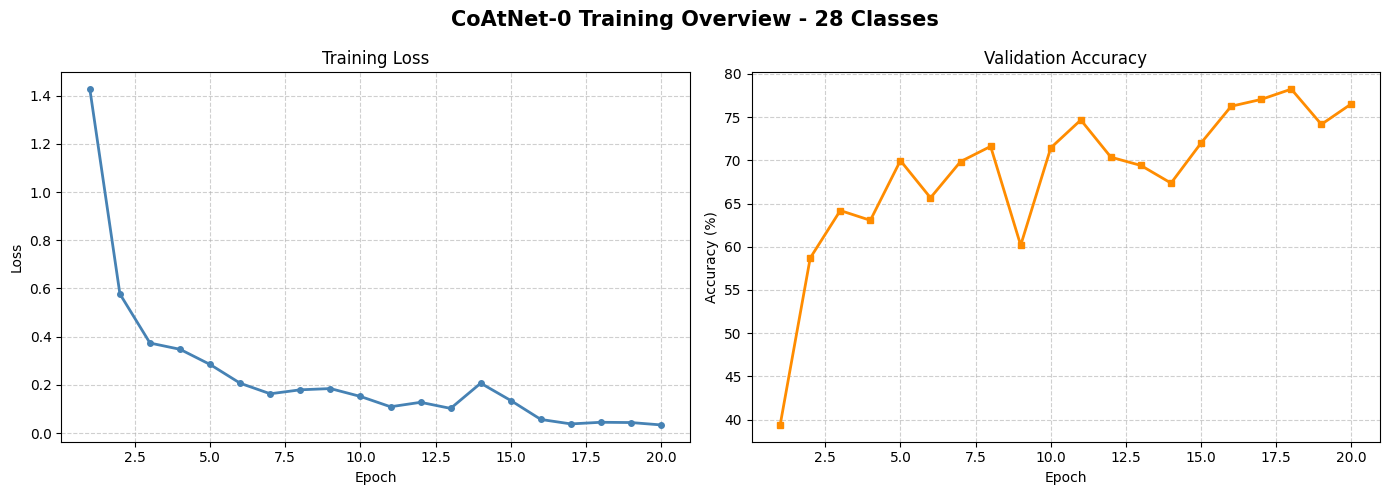

Saved: loss_and_accuracy.png


In [19]:
# two plots next to each other - loss on the left accuracy on the right
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left plot - training loss
axes[0].plot(epochs, train_losses, color="steelblue", linewidth=2, marker="o", markersize=4)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle="--", alpha=0.6)

# right plot - validation accuracy
axes[1].plot(epochs, val_accuracies, color="darkorange", linewidth=2, marker="s", markersize=4)
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("CoAtNet-0 Training Overview - 28 Classes", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/loss_and_accuracy.png", dpi=150)
plt.show()
print("Saved: loss_and_accuracy.png")

## Test Set Evaluation

In [20]:
# loading the best model we saved during training
model.load_state_dict(torch.load(best_model_path))
model.eval()  # setting to eval mode

# empty lists to collect predictions for all test images
all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():  # turning off gradients since we are just testing
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs   = torch.softmax(outputs, dim=1)  # converting scores to probabilities
        _, predicted = torch.max(outputs, 1)     # picking the class with highest score

        all_labels.extend(labels.cpu().numpy())   # saving true labels
        all_preds.extend(predicted.cpu().numpy()) # saving predicted labels
        all_probs.extend(probs.cpu().numpy())     # saving probabilities for auc

# converting to numpy arrays so we can use them with sklearn
all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)

print("Test evaluation done.")

Test evaluation done.


## Performance Summary

In [21]:
# calculating all the metrics we need
precision = precision_score(all_labels, all_preds, average="weighted")
recall    = recall_score(all_labels, all_preds, average="weighted")
f1        = f1_score(all_labels, all_preds, average="weighted")
test_acc  = 100.0 * np.sum(all_labels == all_preds) / len(all_labels)
model_mb  = os.path.getsize(best_model_path) / (1024 * 1024)  # model size in mb

# auc uses one vs rest approach since we have multiple classes
try:
    auc_val = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="weighted")
    auc_str = f"{auc_val:.4f}"
except Exception as e:
    auc_str = f"N/A ({e})"  # in case auc calculation fails

print("=" * 50)
print("        MODEL PERFORMANCE SUMMARY")
print("=" * 50)
print(f"Model            : CoAtNet-0 (coatnet_0_rw_224)")
print(f"Number of classes: 28")
print(f"Training Loss    : {train_losses[-1]:.4f}")
print(f"Val Accuracy     : {best_val_acc:.2f}%")
print(f"Test Accuracy    : {test_acc:.2f}%")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-Score         : {f1:.4f}")
print(f"AUC              : {auc_str}")
print(f"Training Time    : {total_training_time/60:.1f} mins")
print(f"Model Size       : {model_mb:.1f} MB")
print("=" * 50)

        MODEL PERFORMANCE SUMMARY
Model            : CoAtNet-0 (coatnet_0_rw_224)
Number of classes: 28
Training Loss    : 0.0335
Val Accuracy     : 78.24%
Test Accuracy    : 76.72%
Precision        : 0.7755
Recall           : 0.7672
F1-Score         : 0.7655
AUC              : 0.9783
Training Time    : 41.2 mins
Model Size       : 101.9 MB


## Per-Class Report

Shows precision, recall and F1 for all 28 individual classes.

In [22]:
# printing precision recall and f1 for each of the 28 classes one by one
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

                         precision    recall  f1-score   support

            bottle-blue       0.67      0.79      0.73       104
       bottle-blue-full       0.77      0.63      0.69        43
          bottle-blue5l       0.71      0.83      0.76        72
     bottle-blue5l-full       0.86      0.75      0.80        24
            bottle-dark       0.90      0.96      0.93        95
       bottle-dark-full       0.81      0.88      0.85        34
           bottle-green       0.90      0.85      0.88        74
      bottle-green-full       0.79      0.79      0.79        34
            bottle-milk       0.62      0.79      0.70        57
       bottle-milk-full       0.79      0.71      0.75        21
      bottle-multicolor       0.75      0.32      0.45        28
bottle-multicolorv-full       0.77      0.81      0.79        21
             bottle-oil       0.69      0.65      0.67        48
        bottle-oil-full       1.00      0.62      0.77         8
          bottle-transp 

### Graph - Confusion Matrix (28 Classes)

Bigger matrix now since we have 28 classes. Dark diagonal = correct predictions.

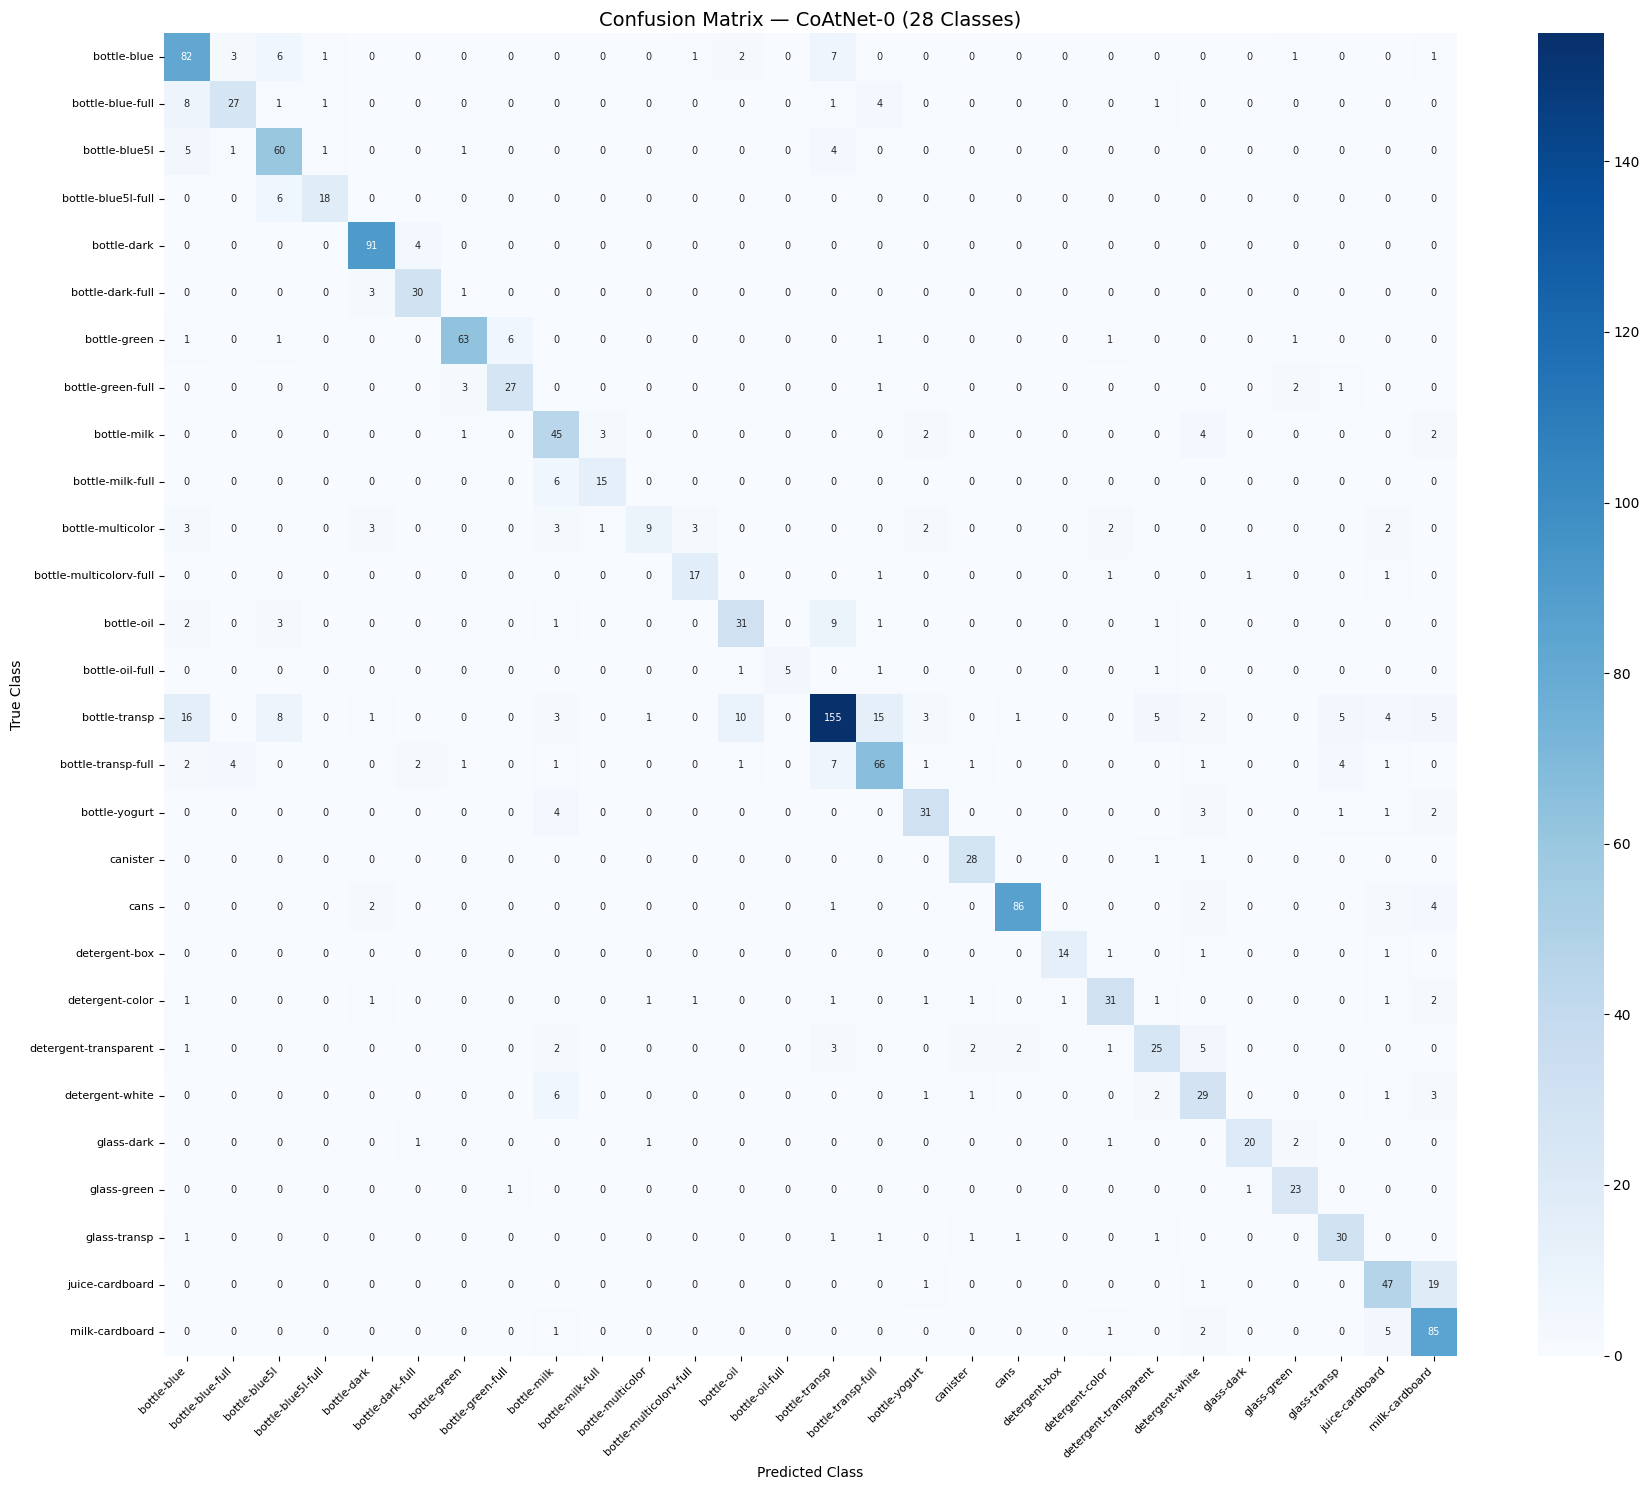

Saved: confusion_matrix.png


In [23]:
# computing the confusion matrix
# rows = what the true class was, columns = what the model predicted
cm = confusion_matrix(all_labels, all_preds)

# making the figure bigger since we have 28 classes
plt.figure(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes,
            annot_kws={"size": 7})  # smaller font so numbers fit inside the cells
plt.title("Confusion Matrix — CoAtNet-0 (28 Classes)", fontsize=14)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("/content/confusion_matrix.png", dpi=150)
plt.show()
print("Saved: confusion_matrix.png")

### Graph - Per-Class Precision, Recall and F1 (28 Classes)

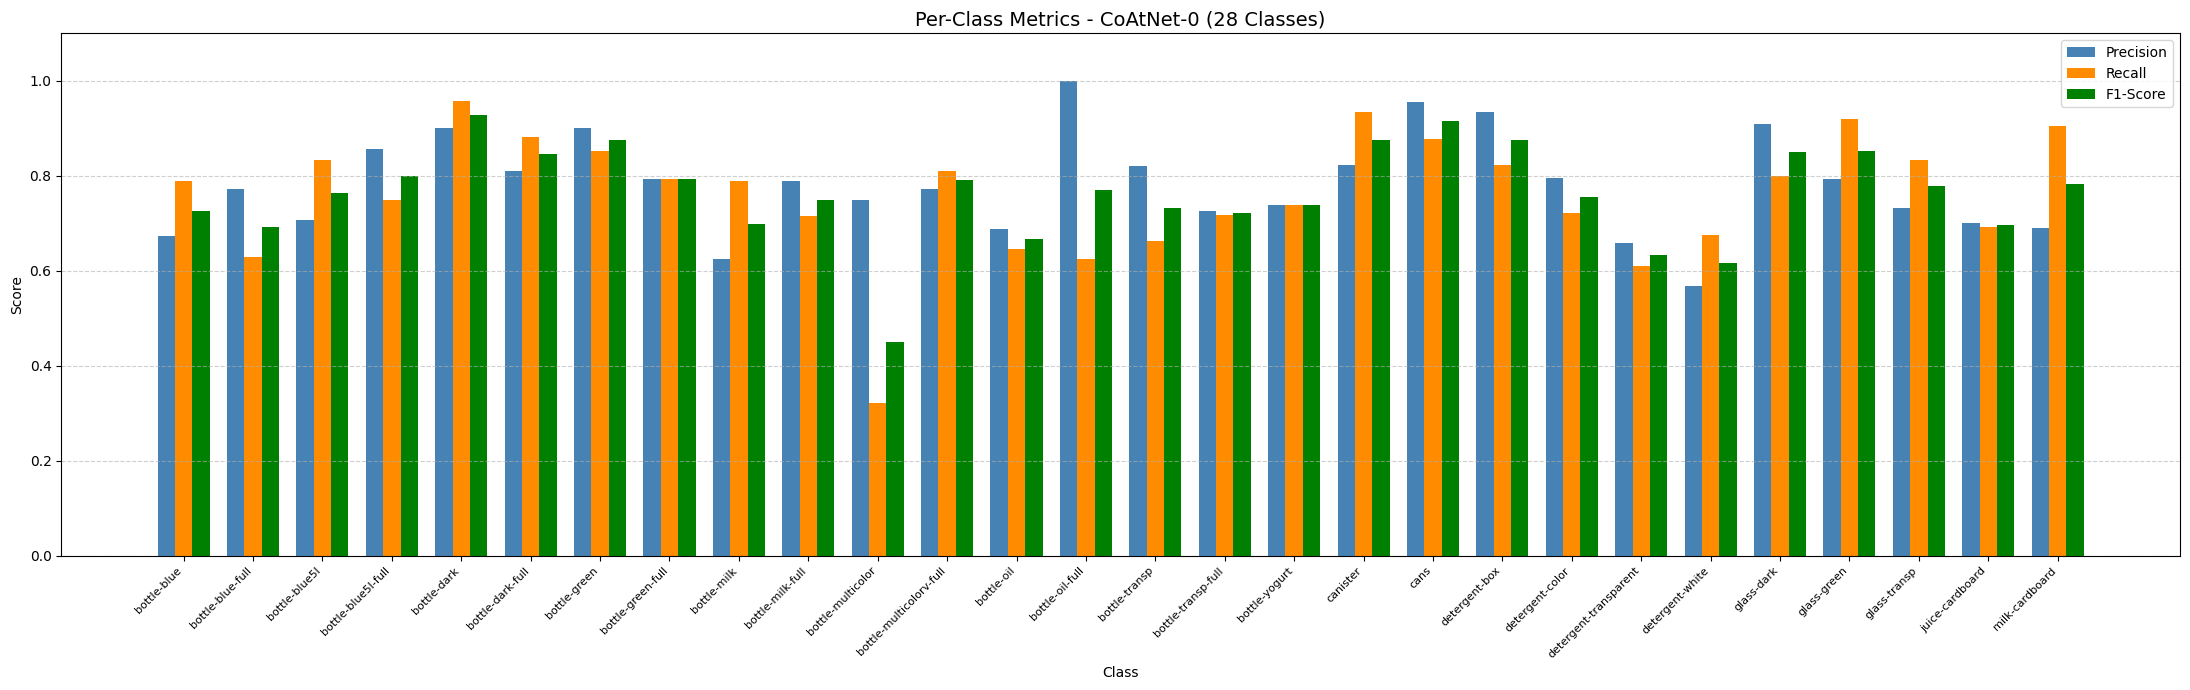

Saved: per_class_metrics.png


In [24]:
# calculating metrics for each class individually not as an average
per_p = precision_score(all_labels, all_preds, average=None)
per_r = recall_score(all_labels, all_preds, average=None)
per_f = f1_score(all_labels, all_preds, average=None)

x     = np.arange(num_classes)  # x positions for each class group
width = 0.25  # width of each bar

# making the figure wider to fit all 28 class names on x axis
plt.figure(figsize=(22, 7))
plt.bar(x - width, per_p, width, label="Precision", color="steelblue")
plt.bar(x,         per_r, width, label="Recall",    color="darkorange")
plt.bar(x + width, per_f, width, label="F1-Score",  color="green")

plt.title("Per-Class Metrics - CoAtNet-0 (28 Classes)", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Score")
plt.xticks(x, train_dataset.classes, rotation=45, ha="right", fontsize=8)
plt.ylim([0, 1.1])
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("/content/per_class_metrics.png", dpi=150)
plt.show()
print("Saved: per_class_metrics.png")

### Graph - ROC Curves (28 Classes)

/tmp/ipykernel_12920/2949783840.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", num_classes)


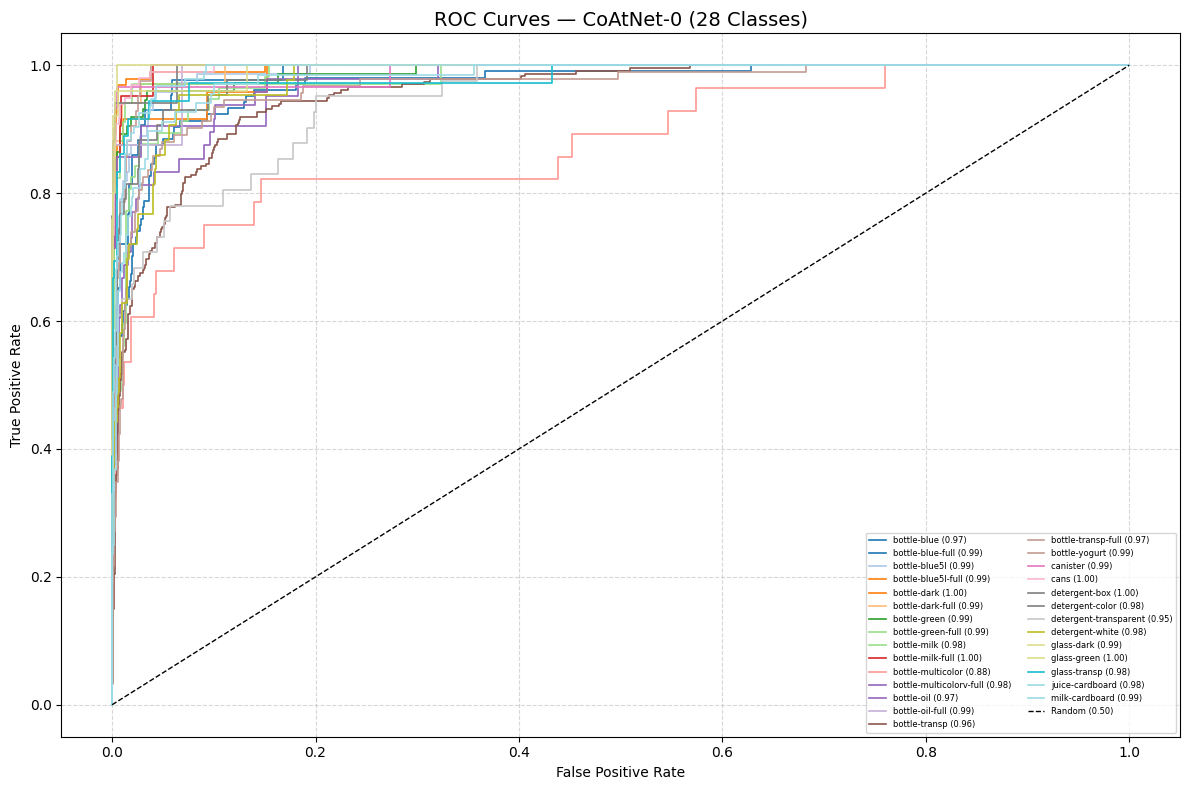

Saved: roc_curves.png


In [25]:
# converting labels to one vs rest format needed to draw roc curves
y_bin = label_binarize(all_labels, classes=list(range(num_classes)))

# using a colormap because we have 28 classes - too many to assign colours manually
cmap = plt.cm.get_cmap("tab20", num_classes)

plt.figure(figsize=(12, 8))

# drawing one curve for each class
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])  # false and true positive rates
    roc_auc     = auc(fpr, tpr)  # area under the curve
    plt.plot(fpr, tpr, color=cmap(i), linewidth=1.2,
             label=f"{train_dataset.classes[i]} ({roc_auc:.2f})")

# dashed line shows what random guessing looks like — auc of 0.50
plt.plot([0,1],[0,1], "k--", linewidth=1, label="Random (0.50)")
plt.title("ROC Curves — CoAtNet-0 (28 Classes)", fontsize=14)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
# using 2 columns in the legend so all 28 labels fit
plt.legend(loc="lower right", fontsize=6, ncol=2)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("/content/roc_curves.png", dpi=150)
plt.show()
print("Saved: roc_curves.png")

## Quantisation

Reduces model size ~4x by converting float32 weights to int8. No retraining needed.

In [26]:
# quantisation makes the model smaller and faster
# it converts weights from float32 (4 bytes) to int8 (1 byte)
# no retraining needed - just applied after training is done
# quantisation only works on cpu so we move the model there first
quantised_model = torch.quantization.quantize_dynamic(
    model.cpu(),
    {nn.Linear},       # only quantising the linear layers
    dtype=torch.qint8  # converting to 8-bit integers
)

# saving the quantised model
quantised_path = "/content/coatnet_quantised_28class.pth"
torch.save(quantised_model.state_dict(), quantised_path)

# comparing file sizes before and after
orig_mb = os.path.getsize(best_model_path) / (1024 * 1024)
qnt_mb  = os.path.getsize(quantised_path)  / (1024 * 1024)

print(f"Original model size  : {orig_mb:.1f} MB")
print(f"Quantised model size : {qnt_mb:.1f} MB")
print(f"Size reduction       : {100*(1 - qnt_mb/orig_mb):.1f}%")

# testing how fast each model processes one image
dummy = torch.randn(1, 3, 224, 224)  # a fake image with the right shape

# timing the original model
original_cpu = model.cpu()
original_cpu.eval()
start = time.time()
with torch.no_grad():
    original_cpu(dummy)
orig_ms = (time.time() - start) * 1000  # converting to milliseconds

# timing the quantised model
quantised_model.eval()
start = time.time()
with torch.no_grad():
    quantised_model(dummy)
qnt_ms = (time.time() - start) * 1000  # converting to milliseconds

print(f"Original inference   : {orig_ms:.1f} ms")
print(f"Quantised inference  : {qnt_ms:.1f} ms")

/tmp/ipykernel_12920/1869640651.py:5: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantised_model = torch.quantization.quantize_dynamic(


Original model size  : 101.9 MB
Quantised model size : 101.9 MB
Size reduction       : 0.1%
Original inference   : 390.9 ms
Quantised inference  : 184.8 ms


### Graph - Model Size and Speed Before vs After Quantisation

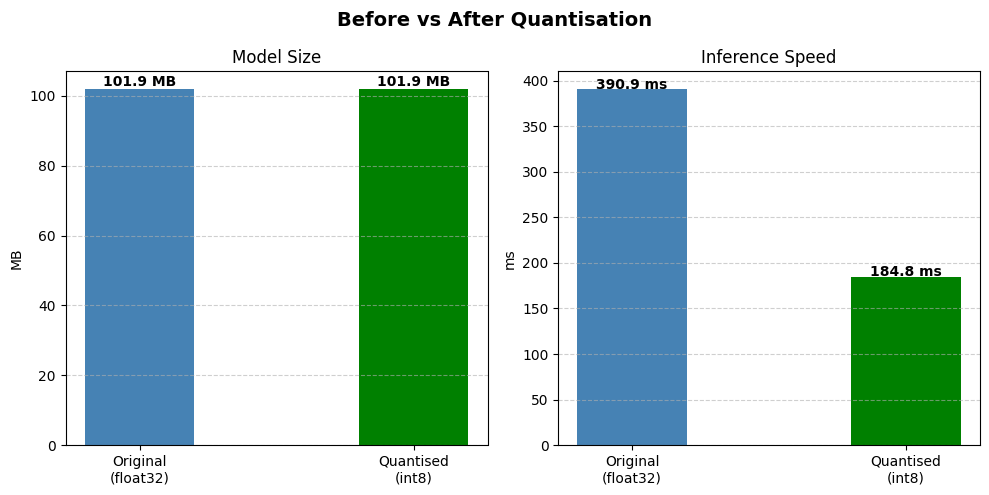

Saved: quantisation_comparison.png


In [27]:
# two bar charts side by side - model size on the left speed on the right
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

labels = ["Original\n(float32)", "Quantised\n(int8)"]  # bar labels

# left - model size comparison
bars1 = axes[0].bar(labels, [orig_mb, qnt_mb], color=["steelblue","green"], width=0.4)
axes[0].set_title("Model Size")
axes[0].set_ylabel("MB")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)
for b, v in zip(bars1, [orig_mb, qnt_mb]):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+1,
                 f"{v:.1f} MB", ha="center", fontweight="bold")  # writing value on top of bar

# right - inference speed comparison
bars2 = axes[1].bar(labels, [orig_ms, qnt_ms], color=["steelblue","green"], width=0.4)
axes[1].set_title("Inference Speed")
axes[1].set_ylabel("ms")
axes[1].grid(axis="y", linestyle="--", alpha=0.6)
for b, v in zip(bars2, [orig_ms, qnt_ms]):
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                 f"{v:.1f} ms", ha="center", fontweight="bold")  # writing value on top of bar

plt.suptitle("Before vs After Quantisation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/quantisation_comparison.png", dpi=150)
plt.show()
print("Saved: quantisation_comparison.png")